## PointNet++ on ModelNet40 — SSG Implementation

## Environment, imports

In [1]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Paths (defensive — works whether launched from project root or notebooks/)
_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
DATA_DIR_M40   = os.path.join(PROJECT_ROOT, "data", "ModelNet40")
CACHE_DIR_M40  = os.path.join(PROJECT_ROOT, "data", "cache_modelnet40_1024pts")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

CLASSES_M40 = sorted([d for d in os.listdir(DATA_DIR_M40)
                      if os.path.isdir(os.path.join(DATA_DIR_M40, d))
                      and not d.startswith(("_", "."))])
CLASS_TO_IDX_M40 = {c: i for i, c in enumerate(CLASSES_M40)}
IDX_TO_CLASS_M40 = {i: c for c, i in CLASS_TO_IDX_M40.items()}

print(f"PyTorch: {torch.__version__}")
print(f"Device : {device}")
print(f"Classes: {len(CLASSES_M40)} (ModelNet40)")

PyTorch: 2.12.0
Device : mps
Classes: 40 (ModelNet40)


## Loading cached point clouds 

In [2]:
class AugmentedCachedModelNet40(Dataset):
    """Cached ModelNet40 with optional z-rotation + jitter augmentation."""
    def __init__(self, cache_path, augment=False, jitter_sigma=0.02, jitter_clip=0.05):
        data = np.load(cache_path)
        self.points = data["points"]
        self.labels = data["labels"]
        self.augment = augment
        self.jitter_sigma = jitter_sigma
        self.jitter_clip = jitter_clip

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        pts = self.points[idx].copy()
        if self.augment:
            theta = np.random.uniform(0, 2 * np.pi)
            c, s = np.cos(theta), np.sin(theta)
            R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
            pts = pts @ R.T
            jitter = np.random.normal(0, self.jitter_sigma, pts.shape).astype(np.float32)
            jitter = np.clip(jitter, -self.jitter_clip, self.jitter_clip)
            pts = pts + jitter
        return torch.from_numpy(pts), int(self.labels[idx])


BATCH_SIZE = 32

train_cache = os.path.join(CACHE_DIR_M40, "train.npz")
test_cache  = os.path.join(CACHE_DIR_M40, "test.npz")

train_aug_m40  = AugmentedCachedModelNet40(train_cache, augment=True)
test_clean_m40 = AugmentedCachedModelNet40(test_cache,  augment=False)

train_loader_m40 = DataLoader(train_aug_m40,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
test_loader_m40  = DataLoader(test_clean_m40, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train (augmented): {len(train_aug_m40)} samples, {len(train_loader_m40)} batches")
print(f"Test  (clean)    : {len(test_clean_m40)} samples, {len(test_loader_m40)} batches")

# Sanity batch
pts, lbls = next(iter(train_loader_m40))
print(f"\nOne batch: points {tuple(pts.shape)}, labels {tuple(lbls.shape)}")

Train (augmented): 9843 samples, 307 batches
Test  (clean)    : 2468 samples, 78 batches

One batch: points (32, 1024, 3), labels (32,)


## Implementing Farthest Point Sampling (FPS)

In [3]:
def farthest_point_sample(xyz, npoint):
    """Farthest Point Sampling.

    Args:
        xyz:    (B, N, 3) input point cloud
        npoint: number of centroids to sample

    Returns:
        (B, npoint) long tensor — indices of sampled points
    """
    B, N, _ = xyz.shape
    device = xyz.device

    # Output: indices of sampled centroids
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    # Running min distance from each point to the chosen centroid set
    distance = torch.full((B, N), float("inf"), device=device)
    # Random starting point per batch element
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=device)
    batch_idx = torch.arange(B, dtype=torch.long, device=device)

    for i in range(npoint):
        # Record this centroid
        centroids[:, i] = farthest
        # Distance from every point to the new centroid (squared L2)
        centroid_xyz = xyz[batch_idx, farthest, :].unsqueeze(1)  # (B, 1, 3)
        dist = ((xyz - centroid_xyz) ** 2).sum(dim=-1)           # (B, N)
        # Update running min-distance to chosen-set
        distance = torch.minimum(distance, dist)
        # Pick the point with maximum distance-to-nearest-centroid
        farthest = distance.argmax(dim=-1)

    return centroids


# Quick correctness check: pull one batch, sample 128 centroids from each cloud
pts, _ = next(iter(train_loader_m40))
pts = pts.to(device)
print(f"Input batch: {tuple(pts.shape)}")

idx = farthest_point_sample(pts, npoint=128)
print(f"FPS indices: {tuple(idx.shape)}  (expected (32, 128))")
print(f"Indices range: {idx.min().item()} to {idx.max().item()}  (expected 0 to 1023)")

# Gather the actual sampled points
sampled = torch.gather(pts, 1, idx.unsqueeze(-1).expand(-1, -1, 3))
print(f"Sampled points: {tuple(sampled.shape)}  (expected (32, 128, 3))")

Input batch: (32, 1024, 3)
FPS indices: (32, 128)  (expected (32, 128))
Indices range: 0 to 1023  (expected 0 to 1023)
Sampled points: (32, 128, 3)  (expected (32, 128, 3))


## Visualize FPS at three scales (1024 → 512 → 128 → 32)


Showing FPS on chair sample 590, shape (1, 1024, 3)


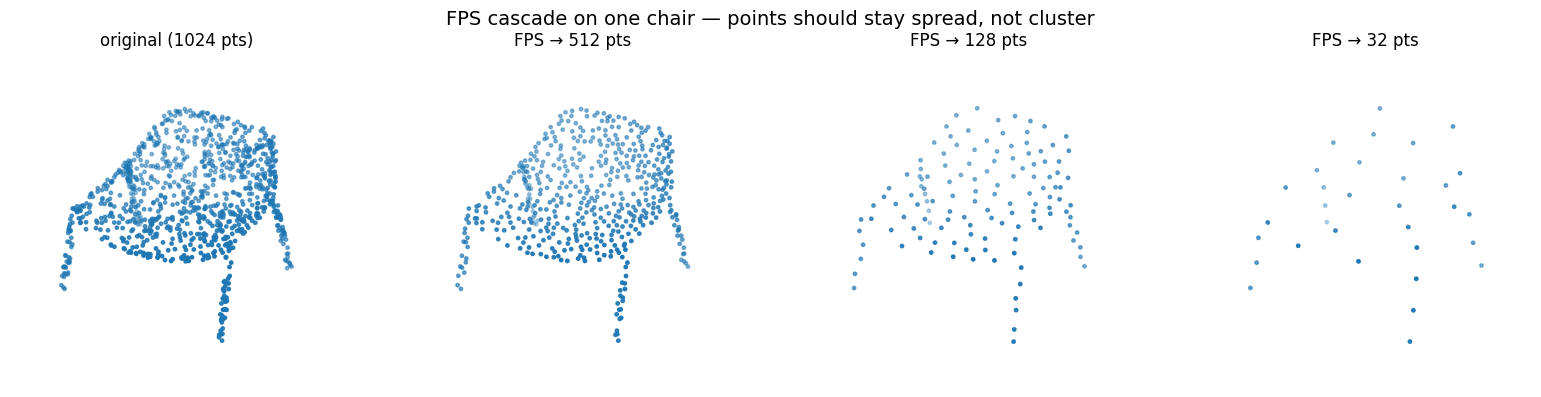


Average nearest-neighbor distance (should grow as we sample fewer points):
   1024 pts: avg NN distance = 0.0187
    512 pts: avg NN distance = 0.0371
    128 pts: avg NN distance = 0.0957
     32 pts: avg NN distance = 0.2432


In [4]:
# Pick a single chair (label 8 = chair in ModelNet40)
chair_idx = int(np.where(test_clean_m40.labels == CLASS_TO_IDX_M40["chair"])[0][0])
chair_pts = torch.from_numpy(test_clean_m40.points[chair_idx]).unsqueeze(0).to(device)  # (1, 1024, 3)
print(f"Showing FPS on chair sample {chair_idx}, shape {tuple(chair_pts.shape)}")

# Run FPS at three target sizes
samples = {}
for npoint in [512, 128, 32]:
    idx = farthest_point_sample(chair_pts, npoint=npoint)
    sampled = torch.gather(chair_pts, 1, idx.unsqueeze(-1).expand(-1, -1, 3))
    samples[npoint] = sampled[0].cpu().numpy()  # (npoint, 3)

orig = chair_pts[0].cpu().numpy()

fig = plt.figure(figsize=(16, 4))
for i, (n_pts, points, title) in enumerate([
    (1024, orig,         "original (1024 pts)"),
    (512,  samples[512], "FPS → 512 pts"),
    (128,  samples[128], "FPS → 128 pts"),
    (32,   samples[32],  "FPS → 32 pts"),
]):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=6)
    ax.set_title(f"{title}")
    ax.set_axis_off()
plt.suptitle("FPS cascade on one chair — points should stay spread, not cluster", fontsize=14)
plt.tight_layout()
plt.show()

# Quantitative sanity: average nearest-neighbor distance should INCREASE as we sample fewer points
# (sparser sampling → bigger gaps between picks)
print("\nAverage nearest-neighbor distance (should grow as we sample fewer points):")
for n_pts, points in [(1024, orig)] + [(n, samples[n]) for n in [512, 128, 32]]:
    pts_t = torch.from_numpy(points)
    pairwise = torch.cdist(pts_t, pts_t)            # (n, n)
    pairwise.fill_diagonal_(float("inf"))           # ignore self-distance
    nn_dist = pairwise.min(dim=1).values.mean().item()
    print(f"  {n_pts:>5} pts: avg NN distance = {nn_dist:.4f}")

## Implementing Ball Query

In [5]:
def index_points(points, idx):
    """Gather points by indices.

    Args:
        points: (B, N, C)
        idx:    (B, S) or (B, S, K) — indices into the N dimension

    Returns:
        (B, S, C) or (B, S, K, C) — the gathered points
    """
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = (
        torch.arange(B, dtype=torch.long, device=points.device)
        .view(view_shape).repeat(repeat_shape)
    )
    return points[batch_indices, idx, :]


def ball_query(radius, nsample, xyz, new_xyz):
    """Find up to `nsample` points within `radius` of each query point.

    Args:
        radius:  float — search radius
        nsample: int — max neighbors per query
        xyz:     (B, N, 3) — all input points
        new_xyz: (B, S, 3) — query points (FPS centroids)

    Returns:
        (B, S, nsample) — long tensor of indices into xyz's N dimension
    """
    B, N, _ = xyz.shape
    _, S, _ = new_xyz.shape
    device = xyz.device

    # Start with all-N indices in shape (B, S, N)
    group_idx = (
        torch.arange(N, dtype=torch.long, device=device)
        .view(1, 1, N).repeat(B, S, 1)
    )

    # Pairwise squared distance from each query to every input point: (B, S, N)
    sqrdists = ((new_xyz.unsqueeze(2) - xyz.unsqueeze(1)) ** 2).sum(dim=-1)

    # Mark out-of-radius points as "invalid" by setting their index to N (out of range)
    group_idx[sqrdists > radius ** 2] = N

    # Sort indices so valid ones come first, then take the first `nsample`
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]

    # If a query has fewer than nsample valid neighbors, duplicate the closest valid one
    group_first = group_idx[:, :, 0:1].repeat(1, 1, nsample)
    mask = group_idx == N
    group_idx[mask] = group_first[mask]

    return group_idx


# Quick correctness check on one batch
pts, _ = next(iter(train_loader_m40))
pts = pts.to(device)

# Pick 128 centroids with FPS, then find 32 neighbors per centroid within radius 0.2
fps_idx = farthest_point_sample(pts, npoint=128)
centroids = index_points(pts, fps_idx)
print(f"Centroids: {tuple(centroids.shape)}  (expected (32, 128, 3))")

nn_idx = ball_query(radius=0.2, nsample=32, xyz=pts, new_xyz=centroids)
print(f"Ball query indices: {tuple(nn_idx.shape)}  (expected (32, 128, 32))")
print(f"Index range: {nn_idx.min().item()} to {nn_idx.max().item()}  (expected 0 to 1023)")

# Sanity: gather the actual neighbor points and verify they are within radius
neighbors = index_points(pts, nn_idx)  # (B, S, K, 3)
print(f"Gathered neighbors: {tuple(neighbors.shape)}  (expected (32, 128, 32, 3))")

# Distance from centroid to each of its neighbors — should all be ≤ 0.2 (with possible duplicates of the closest one for padded entries)
diffs = neighbors - centroids.unsqueeze(2)
dists = diffs.pow(2).sum(-1).sqrt()
print(f"Max neighbor distance: {dists.max().item():.4f}  (should be ≤ 0.2)")
print(f"Mean neighbor distance: {dists.mean().item():.4f}")

Centroids: (32, 128, 3)  (expected (32, 128, 3))
Ball query indices: (32, 128, 32)  (expected (32, 128, 32))
Index range: 0 to 1023  (expected 0 to 1023)
Gathered neighbors: (32, 128, 32, 3)  (expected (32, 128, 32, 3))
Max neighbor distance: 0.2000  (should be ≤ 0.2)
Mean neighbor distance: 0.1366


## Visualize Ball Query

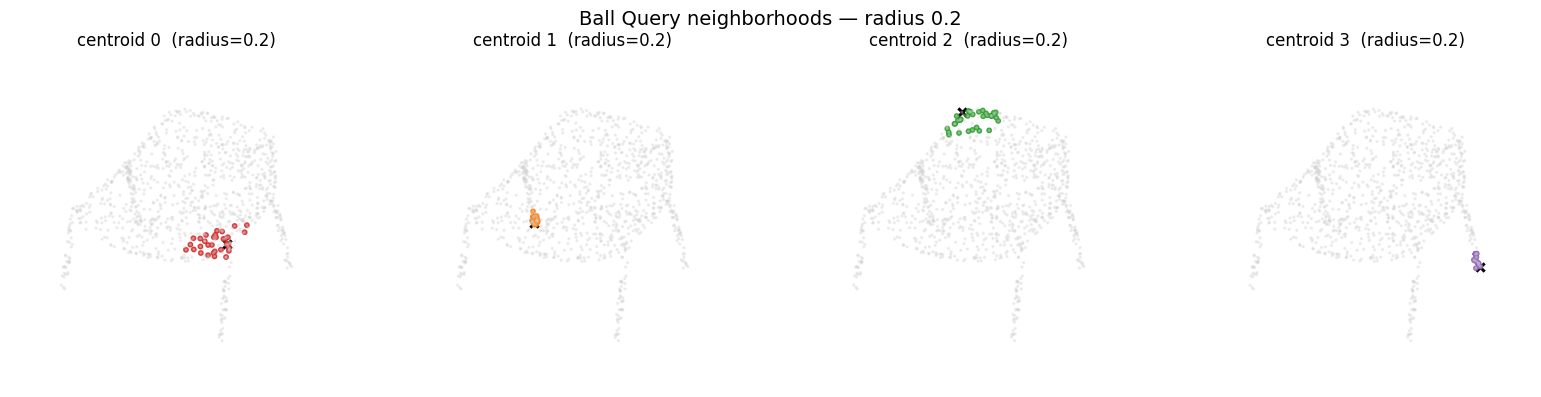

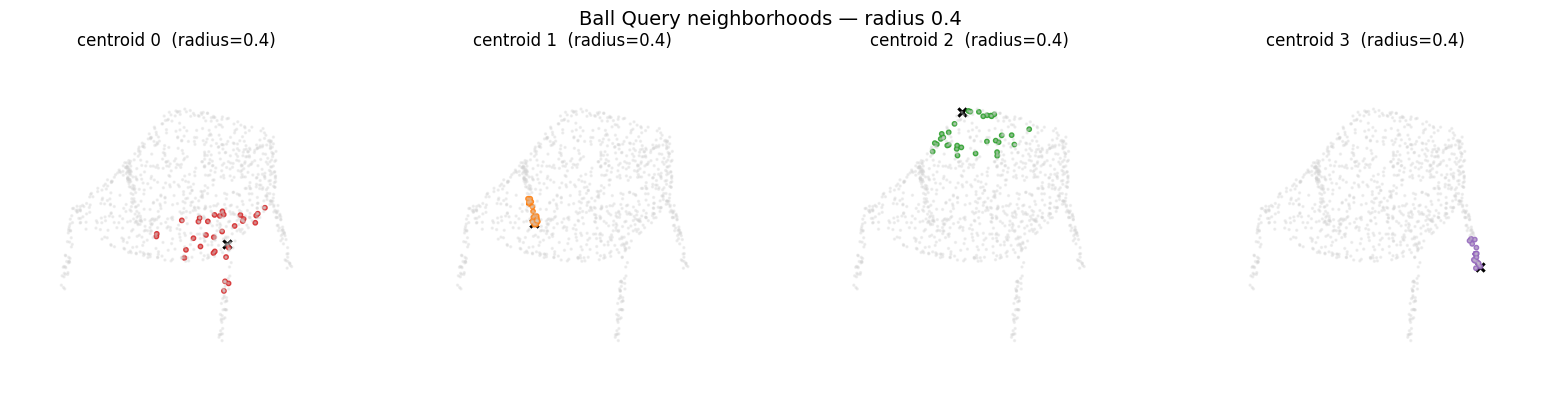

In [6]:
chair_idx = int(np.where(test_clean_m40.labels == CLASS_TO_IDX_M40["chair"])[0][0])
chair_pts = torch.from_numpy(test_clean_m40.points[chair_idx]).unsqueeze(0).to(device)  # (1, 1024, 3)

# Sample 4 well-spread centroids
fps_idx_demo = farthest_point_sample(chair_pts, npoint=4)
centroids_demo = index_points(chair_pts, fps_idx_demo)  # (1, 4, 3)

# Ball query with two different radii so we can visually compare
for radius in [0.2, 0.4]:
    nn_idx_demo = ball_query(radius=radius, nsample=32, xyz=chair_pts, new_xyz=centroids_demo)
    # For each of the 4 centroids, gather its 32 neighbors
    neighbors_demo = index_points(chair_pts, nn_idx_demo)  # (1, 4, 32, 3)

    fig = plt.figure(figsize=(16, 4))
    chair_np = chair_pts[0].cpu().numpy()
    centroid_np = centroids_demo[0].cpu().numpy()
    colors = ["tab:red", "tab:orange", "tab:green", "tab:purple"]

    for q in range(4):
        ax = fig.add_subplot(1, 4, q + 1, projection="3d")
        # background: full chair in light gray
        ax.scatter(chair_np[:, 0], chair_np[:, 1], chair_np[:, 2], s=2, c="lightgray", alpha=0.3)
        # this centroid's neighbors in color
        nbrs = neighbors_demo[0, q].cpu().numpy()
        ax.scatter(nbrs[:, 0], nbrs[:, 1], nbrs[:, 2], s=10, c=colors[q], alpha=0.85)
        # the centroid itself in black
        ax.scatter(centroid_np[q, 0], centroid_np[q, 1], centroid_np[q, 2],
                   s=80, c="black", marker="X", edgecolors="white", linewidths=1)
        ax.set_title(f"centroid {q}  (radius={radius})")
        ax.set_axis_off()

    plt.suptitle(f"Ball Query neighborhoods — radius {radius}", fontsize=14)
    plt.tight_layout()
    plt.show()